# 06 · Drift monitoring: ¿cómo sabemos cuándo el modelo dejó de ser confiable?

**Fase CRISP-DM:** despliegue (simulado). Responde la
pregunta 4 del proyecto. No hay un sistema en operación: el despliegue se simula con un modelo congelado y el
monitoreo se ejecuta sobre datos históricos.

Un modelo en producción se degrada cuando el mundo cambia. El monitoreo de drift busca **detectar esos
cambios a tiempo** y **distinguir** los que importan de los que no.

### Escenario simulado
El modelo del Problema 1 (L1 sobre cambio relativo, h = 1) se **entrena una vez** con datos hasta
diciembre 2025 y se **despliega sin reentrenar** durante enero–agosto 2026. En 2026 ocurrió un **shock de
precios de commodities conocido** (EDA §5), así que sirve para verificar si el sistema lo detecta.

Para medir **falsas alarmas** se corre el mismo sistema en un **período de control** sin eventos conocidos:
un modelo entrenado hasta junio 2025 y monitoreado en julio–diciembre 2025.

### Cuatro capas

| Capa | Pregunta | Métricas | Cuándo se puede medir |
|---|---|---|---|
| **0. Calidad de datos** | ¿Llegaron bien los datos? | Filas descartadas, valores no convertibles, volumen vs mismo mes del año anterior, valor con códigos nuevos | Al recibir el archivo |
| **1. Data drift** | ¿Cambiaron las entradas? | **PSI** y **KS** por feature; **mix por capítulo ponderado por valor**; **índice de precios implícito** | Antes de conocer el resultado |
| **2. Target drift** | ¿Cambió la distribución del objetivo? | PSI del objetivo | Un mes después |
| **3. Concept drift / desempeño** | ¿Cambió la relación entradas → objetivo? | WAPE y sesgo del modelo congelado (**gráfico de control**); brecha congelado vs reentrenado | Un mes después |

### Métricas
- **PSI** = Σ (%actual − %ref) · ln(%actual / %ref), sobre los deciles de la referencia (NaN = bin propio).
  Convención de la industria: **< 0,10 estable · 0,10–0,25 advertencia · > 0,25 alerta**.
- **KS:** se reporta el **estadístico D** (máxima distancia entre las distribuciones acumuladas), **no el
  p-value**. Con decenas de miles de filas, cualquier diferencia ínfima es "estadísticamente significativa":
  significancia estadística no es relevancia práctica.
- **Gráfico de control (Shewhart):** z = (valor − μ_ref) / σ_ref, donde μ y σ vienen del **desempeño del propio
  modelo** en la referencia. Advertencia si |z| > 2; alerta si |z| > 3, o 2 advertencias seguidas del mismo signo.
- **Índice de precios implícito:** Σ w · log(valor unitario / mediana de referencia) / Σ w, con w = valor del
  mes, por segmento. Tolerancia de negocio: ±10% advertencia, ±20% alerta.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from comercio_chile import viz, drift as D
from comercio_chile.features import load_grid

viz.setup(); warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
M = lambda a, b: [str(p) for p in pd.period_range(a, b, freq="M")]
FLOWS = ["exportaciones", "importaciones"]
G = {f: load_grid(f) for f in FLOWS}
ESCENARIOS = {"control": dict(cut="2025-06", months=M("2025-07", "2025-12"), perf_ref_months=M("2025-03", "2025-06")),
              "evento 2026": dict(cut="2025-12", months=M("2026-01", "2026-08"), perf_ref_months=M("2025-07", "2025-12"))}
R = {(f, e): D.run(G[f], **cfg) for f in FLOWS for e, cfg in ESCENARIOS.items()}
for (f, e), r in R.items():
    print(f"{f:14s} {e:12s} referencia de features: orígenes {r['ref_origins'][0]}..{r['ref_origins'][-1]}")

exportaciones  control      referencia de features: orígenes 2025-03..2025-05
exportaciones  evento 2026  referencia de features: orígenes 2025-03..2025-11
importaciones  control      referencia de features: orígenes 2025-03..2025-05
importaciones  evento 2026  referencia de features: orígenes 2025-03..2025-11


## 0. Calidad de datos (capa 0)

In [2]:
dq = pd.concat({f: D.data_quality(f, M("2026-01", "2026-08"), M("2025-01", "2025-12")) for f in FLOWS})
dq.round(2)

filas  Δ volumen vs año anterior %  % filas reparadas  filas descartadas  valores no convertibles  % valor con códigos nuevos estado
              periodo                                                                                                                                       
exportaciones 2026-01  124067                        -2.69                0.0                  0                        0                        0.01     ok
              2026-02   94067                        -4.42                0.0                  0                        0                        0.01     ok
              2026-03  109187                         8.15                0.0                  0                        0                        0.02     ok
              2026-04  102350                        -9.24                0.0                  0                        0                        0.01     ok
              2026-05   88867                        -3.27                0.0                  0                        0                        0.01     ok
              2026-06   97270                        11.80                0.0                  0                        0                        0.02     ok
              2026-07   99589                        -4.76                0.0                  0                        0                        0.01     ok
              2026-08   95038                         7.40                0.0                  0                        0                        0.01     ok
importaciones 2026-01  380834                        -0.57                0.0                  0                        0                        0.00     ok
              2026-02  354508                        -0.13                0.0                  0                        0                        0.03     ok
              2026-03  439353                        13.86                0.0                  0                        0                        0.04     ok
              2026-04  408027                         4.38                0.0                  0                        0                        0.01     ok
              2026-05  388782                        -3.82                0.0                  0                        0                        0.01     ok
              2026-06  402127                         0.32                0.0                  0                        0                        0.01     ok
              2026-07  447201                        -0.28                0.0                  0                        0                        0.01     ok
              2026-08  425587                         1.95                0.0                  0                        0                        0.10     ok

Los archivos de 2026 llegan íntegros: 0 filas descartadas, 0 valores no convertibles, volumen dentro de
±15% del mismo mes de 2025, y < 0,1% del valor con productos o países nunca vistos. **Esta capa va primero
porque es la más barata y la que puede invalidar todo lo demás**: si el archivo viene corrupto, no tiene
sentido medir drift.

> *Lección:* la primera versión comparaba el volumen contra el promedio anual y marcaba advertencia en enero
> 2026, el mes de mayor volumen por la temporada de fruta. El monitoreo también debe respetar la
> **estacionalidad**: el volumen se compara con el mismo mes del año anterior.

## 1. Lecciones del período de control: un monitoreo ingenuo da falsas alarmas

Antes de mirar 2026, el sistema se corrió sobre el período de control. Ahí aparecieron tres problemas de
diseño, que se corrigieron **antes** de evaluar el evento.

In [3]:
g = G["exportaciones"]
t_cut = g.t_of("2025-06")
cur = D.feature_frame(g, [g.t_of("2025-07") - 1])
ref_con_calentamiento = D.feature_frame(g, list(range(11, t_cut)))      # incluye orígenes sin historia completa
ref_correcta = D.feature_frame(g, list(range(D.FULL_ORIGIN, t_cut)))
pd.DataFrame({
    "PSI con referencia ingenua": {c: D.psi(ref_con_calentamiento[c], cur[c]) for c in ["crec_interanual_3m", "lag_12", "cap_crec_interanual"]},
    "% NaN en referencia ingenua": {c: 100 * ref_con_calentamiento[c].isna().mean() for c in ["crec_interanual_3m", "lag_12", "cap_crec_interanual"]},
    "PSI con referencia corregida": {c: D.psi(ref_correcta[c], cur[c]) for c in ["crec_interanual_3m", "lag_12", "cap_crec_interanual"]},
}).round(3)

,PSI con referencia ingenua,% NaN en referencia ingenua,PSI con referencia corregida
crec_interanual_3m,4.597,49.893,0.006
lag_12,1.270,16.637,0.010
cap_crec_interanual,2.096,16.637,0.569


1. **Falsas alarmas por datos faltantes estructurales.** `crec_interanual_3m` necesita 15 meses de historia:
   en los primeros orígenes de la referencia ingenua es NaN, y el PSI compara "mucho NaN" con "nada NaN".
   **Corrección:** la referencia solo usa orígenes con todas las features definidas (desde mar-2025).
2. **Features que por diseño cambian cada mes.** `cap_crec_interanual` (crecimiento del capítulo) toma ~97
   valores por mes y es una tasa de crecimiento: **no se espera que sea estable**, y su PSI es alto incluso
   con la referencia corregida. **Corrección:** las features de contexto se monitorean por su **nivel**, no
   por PSI.
3. **Umbral de sesgo mal calibrado.** El modelo L1 estima la **mediana**, así que su sesgo normal es negativo
   (≈ −7% a −14%), no cero. Un umbral fijo de ±10% dispara alarmas en meses normales. **Corrección:**
   umbrales calibrados con el comportamiento del propio modelo (gráfico de control).

## 2. Data drift: PSI por feature

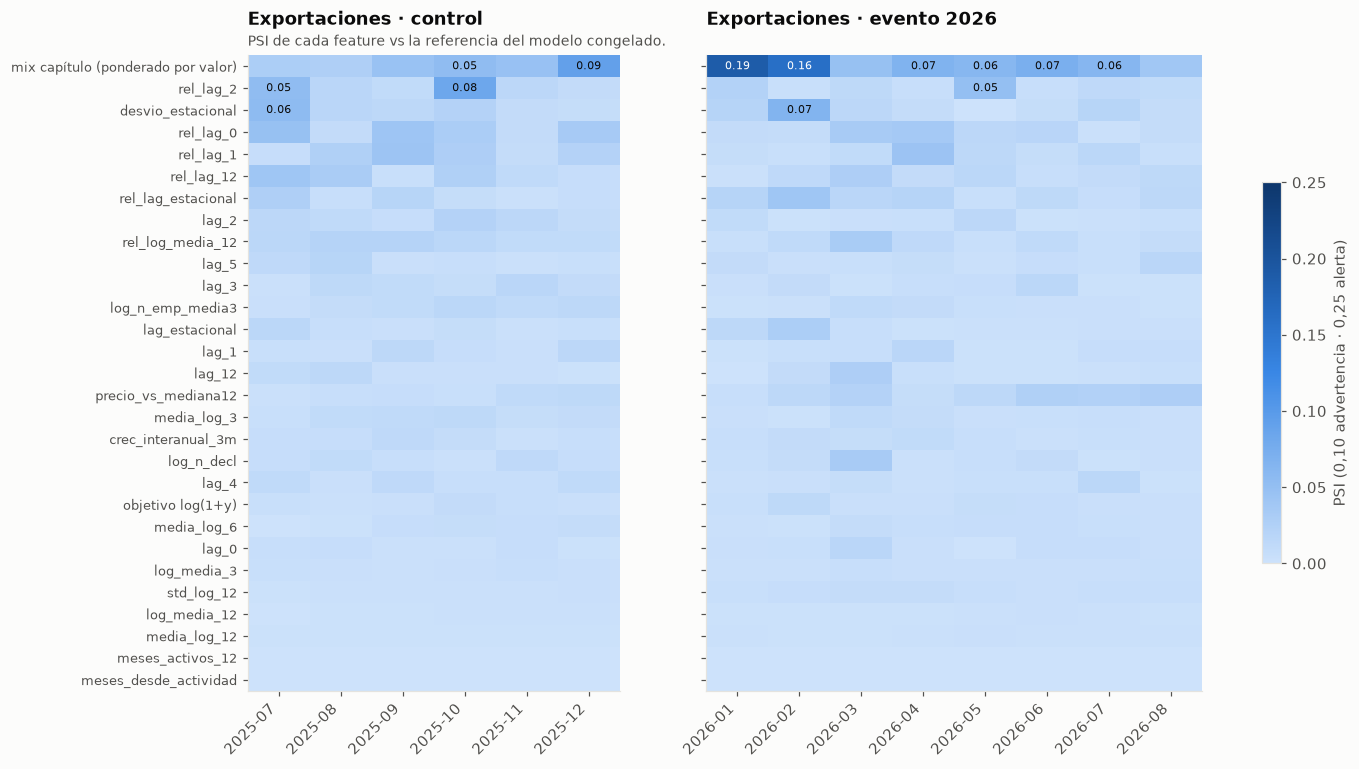

In [4]:
cmap = LinearSegmentedColormap.from_list("seq", viz.SEQ_BLUE)
fig, axes = plt.subplots(1, 2, figsize=(14, 7.5), gridspec_kw={"width_ratios": [6, 8]}, sharey=True)
for ax, e in zip(axes, ESCENARIOS):
    d = R[("exportaciones", e)]["drift"]
    piv = d[d.tipo != "contexto"].pivot_table(index="feature", columns="periodo", values="PSI")
    if e == "control":
        order = piv.max(axis=1).sort_values(ascending=False).index
    piv = piv.reindex(order)
    im = ax.imshow(piv.values, cmap=cmap, vmin=0, vmax=0.25, aspect="auto")
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            v = piv.values[i, j]
            if v >= 0.05:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7.5, color="white" if v > 0.15 else viz.TEXT)
    ax.set_xticks(range(piv.shape[1]), piv.columns, rotation=45, ha="right")
    ax.set_yticks(range(piv.shape[0]), piv.index, fontsize=8.5); ax.grid(False)
    ax.set_title(f"Exportaciones · {e}")
fig.colorbar(im, ax=axes, shrink=0.6, label="PSI (0,10 advertencia · 0,25 alerta)")
viz.subtitle(axes[0], "PSI de cada feature vs la referencia del modelo congelado.")
viz.save(fig, "21_psi_heatmap"); fig

In [5]:
resumen = []
for (f, e), r in R.items():
    d = r["drift"]
    s = d[d.tipo == "serie"]
    resumen.append({"flujo": f, "escenario": e, "PSI máx. features por serie": s.PSI.max(),
                    "PSI máx. objetivo": d[d.tipo == "objetivo"].PSI.max(),
                    "PSI máx. mix por valor": d[d.tipo == "composición"].PSI.max(),
                    "KS máx. features": s.KS.max()})
pd.DataFrame(resumen).set_index(["flujo", "escenario"]).round(3)

PSI máx. features por serie  PSI máx. objetivo  PSI máx. mix por valor  KS máx. features
flujo         escenario                                                                                            
exportaciones control                            0.083              0.010                   0.091             0.133
              evento 2026                        0.065              0.013                   0.188             0.114
importaciones control                            0.049              0.004                   0.051             0.105
              evento 2026                        0.044              0.017                   0.066             0.098

**El shock de 2026 no aparece en el PSI de las features ni del objetivo, y eso es correcto.**
El PSI mide la distribución **entre series**: qué hacen las ~2.900 series de exportación. Esa distribución
casi no cambió. El shock afectó el **precio de unas pocas series gigantes** (cobre, litio, oro), y en una
métrica por conteo esas pocas series quedan diluidas entre miles.

**Solo las métricas ponderadas por valor lo detectan:** el **mix por capítulo ponderado por valor** sube a
PSI ≈ 0,19 en enero 2026 (advertencia), cuando en el período de control nunca superó 0,10.

**Lección de diseño:** en datos concentrados, el monitoreo debe incluir señales **ponderadas por la métrica de
negocio**, no solo por conteo de observaciones.

Además, las features del modelo son **relativas al nivel reciente** (`rel_*`), por lo que un cambio de nivel de
precios no altera su distribución. Ese diseño hace al modelo **robusto** al drift de nivel (§4).

## 3. Panel de monitoreo: precios, desempeño y sesgo

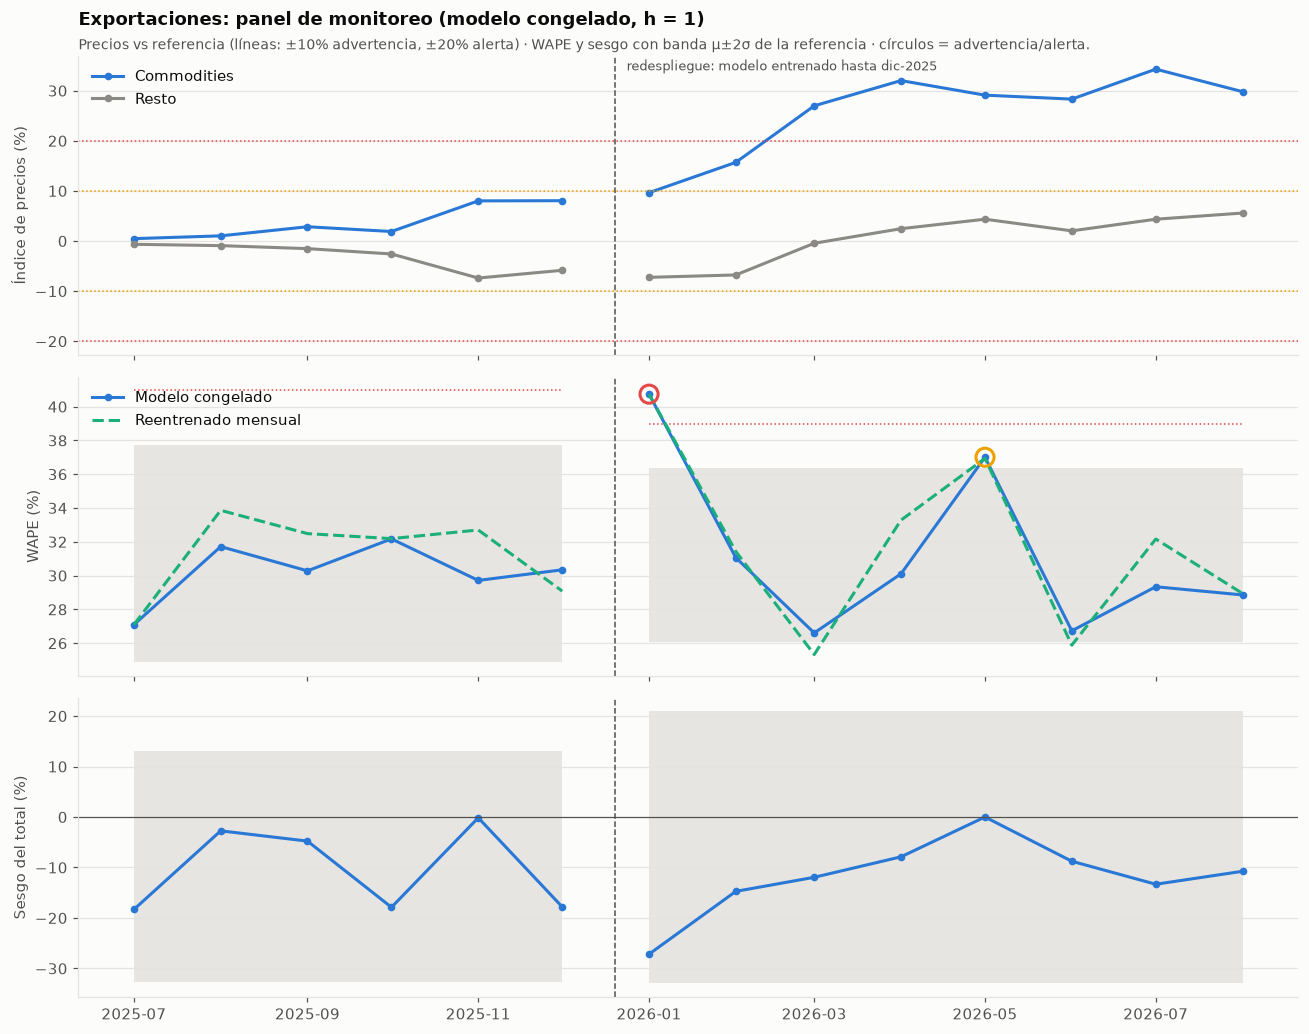

In [6]:
def panel(flow, fname):
    fig, axes = plt.subplots(3, 1, figsize=(12, 9.5), sharex=True)
    for e, r in [(e, R[(flow, e)]) for e in ESCENARIOS]:
        p = r["perf"].copy(); x = pd.PeriodIndex(p.periodo, freq="M").to_timestamp()
        rp = r["ref_perf"]
        # (a) precios
        axes[0].plot(x, 100 * p.precio_commodities, color=viz.SERIES[0], marker="o", markersize=4, label="Commodities" if e == "control" else None)
        axes[0].plot(x, 100 * p.precio_resto, color=viz.NEUTRAL, marker="o", markersize=4, label="Resto" if e == "control" else None)
        # (b) WAPE con banda de control
        mu, sd = rp.WAPE.mean(), rp.WAPE.std(ddof=1)
        axes[1].fill_between(x, 100 * (mu - 2 * sd), 100 * (mu + 2 * sd), color=viz.GRID, alpha=0.9, lw=0)
        axes[1].plot(x, [100 * (mu + 3 * sd)] * len(x), color=viz.SERIES[7], ls=":", lw=1)
        axes[1].plot(x, 100 * p.WAPE, color=viz.SERIES[0], marker="o", markersize=4, label="Modelo congelado" if e == "control" else None)
        axes[1].plot(x, 100 * p.WAPE_reentrenado, color=viz.SERIES[2], ls="--", label="Reentrenado mensual" if e == "control" else None)
        # (c) sesgo con banda de control
        mu, sd = rp.sesgo_total.mean(), rp.sesgo_total.std(ddof=1)
        axes[2].fill_between(x, 100 * (mu - 2 * sd), 100 * (mu + 2 * sd), color=viz.GRID, alpha=0.9, lw=0)
        axes[2].plot(x, 100 * p.sesgo, color=viz.SERIES[0], marker="o", markersize=4)
        for ax, col in [(axes[1], "control_WAPE"), (axes[2], "control_sesgo")]:
            vals = 100 * (p.WAPE if col == "control_WAPE" else p.sesgo)
            for xx, st, v in zip(x, p[col], vals):
                if st != D.OK:
                    ax.scatter([xx], [v], s=140, facecolors="none", edgecolors=viz.SERIES[7] if st == D.ALERT else viz.SERIES[3], linewidths=2, zorder=4)
    for ax in axes:
        ax.axvline(pd.Timestamp("2025-12-20"), color=viz.TEXT_2, ls="--", lw=1)
    for y_, c in [(10, viz.SERIES[3]), (20, viz.SERIES[7])]:
        axes[0].axhline(y_, color=c, ls=":", lw=1); axes[0].axhline(-y_, color=c, ls=":", lw=1)
    axes[0].text(pd.Timestamp("2025-12-24"), axes[0].get_ylim()[1] * 0.92, "redespliegue: modelo entrenado hasta dic-2025", fontsize=8.5, color=viz.TEXT_2)
    axes[0].set_ylabel("Índice de precios (%)"); axes[0].legend(loc="upper left")
    axes[0].set_title(f"{flow.capitalize()}: panel de monitoreo (modelo congelado, h = 1)")
    viz.subtitle(axes[0], "Precios vs referencia (líneas: ±10% advertencia, ±20% alerta) · WAPE y sesgo con banda μ±2σ de la referencia · círculos = advertencia/alerta.")
    axes[1].set_ylabel("WAPE (%)"); axes[1].legend(loc="upper left")
    axes[2].set_ylabel("Sesgo del total (%)"); axes[2].axhline(0, color=viz.TEXT_2, lw=0.8)
    fig.tight_layout()
    viz.save(fig, fname)
    return fig

panel("exportaciones", "22_panel_drift_exportaciones")

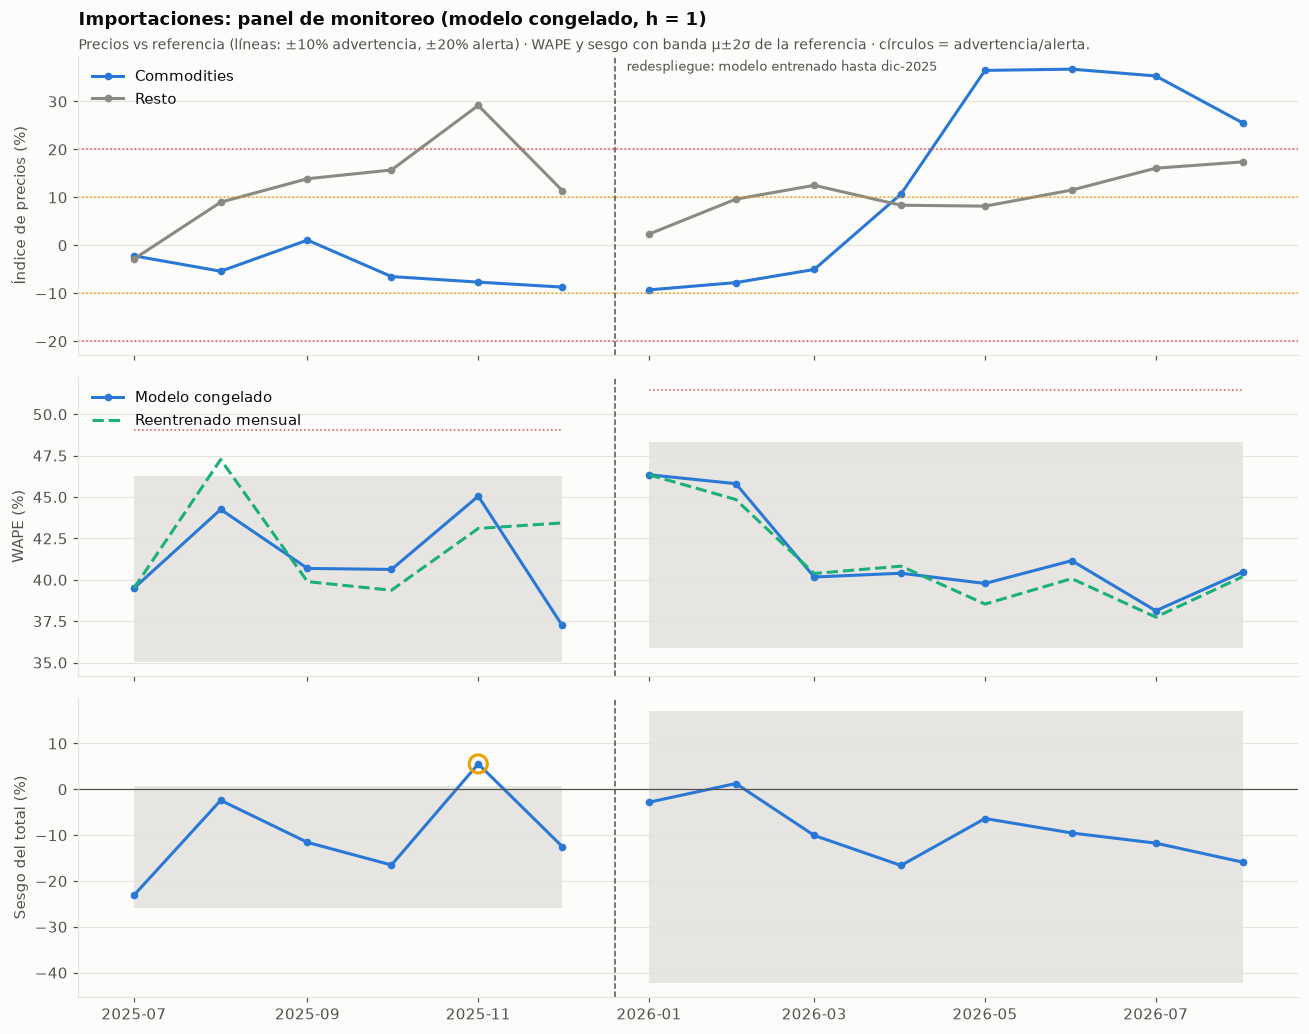

In [7]:
panel("importaciones", "23_panel_drift_importaciones")

## 4. Diagnóstico: ¿data drift, concept drift o ambos?

In [8]:
rows = []
for (f, e), r in R.items():
    p = r["perf"]
    rows.append({"flujo": f, "escenario": e,
                 "WAPE ref. (μ)": r["ref_perf"].WAPE.mean(), "WAPE congelado": p.WAPE.mean(),
                 "WAPE reentrenado": p.WAPE_reentrenado.mean(),
                 "pérdida por no reentrenar (pp)": 100 * (p.WAPE.mean() - p.WAPE_reentrenado.mean()),
                 "precio commodities máx. (%)": 100 * p.precio_commodities.abs().max()})
pd.DataFrame(rows).set_index(["flujo", "escenario"]).round(3)

WAPE ref. (μ)  WAPE congelado  WAPE reentrenado  pérdida por no reentrenar (pp)  precio commodities máx. (%)
flujo         escenario                                                                                                                
exportaciones control              0.313           0.302             0.312                          -1.015                        8.045
              evento 2026          0.312           0.313             0.318                          -0.532                       34.300
importaciones control              0.406           0.412             0.421                          -0.869                        8.719
              evento 2026          0.421           0.415             0.411                           0.414                       36.740

**Lectura del caso exportaciones 2026:**
1. **Hubo un cambio fuerte en los datos:** el índice de precios de commodities llega a **+34%** en julio. El
   sistema marca **advertencia en febrero (+16%) y alerta desde marzo**; enero (+9,7%) quedó justo bajo la
   tolerancia. Ya en nov–dic 2025 (período de control) mostraba +8%: una **señal temprana**, aunque bajo el
   umbral.
2. **El desempeño se degradó solo en enero 2026** (WAPE fuera de la banda de control, z ≈ 3,7) y luego volvió
   a la normalidad **sin reentrenar**.
3. **El modelo congelado y el reentrenado rinden casi igual en 2026:** reentrenar no habría ayudado mucho.

**Diagnóstico: data drift persistente con concept drift transitorio.** El modelo usa features **relativas al
nivel reciente**: cuando los precios suben, el "nivel" se actualiza en 1–3 meses y el modelo vuelve a
funcionar. Enero fue el mes de transición, cuando el salto ocurrió antes de que el nivel lo reflejara.

**Importaciones:** también hubo un alza de precios de los commodities importados (dominados en valor por
combustibles, cap. 27): **advertencia en abril y alerta desde mayo (+36%)**, sin degradación del desempeño.
Es el mismo patrón: el diseño relativo absorbe el cambio de nivel.

**Dos observaciones sobre las señales:**
- **El gráfico de control del sesgo es poco sensible.** El sesgo mensual varía tanto en la referencia
  (σ ≈ 8–9 pp) que ni el −27% de enero 2026 sale de la banda. **La señal útil de desempeño fue el WAPE.**
  Con más meses de referencia, la banda se estimaría mejor.
- **El índice de precios solo alerta en commodities.** En el segmento "resto" el valor unitario mezcla
  productos heterogéneos ("una unidad" de maquinaria no es comparable entre envíos), y por eso es ruidoso: en
  importaciones llegó a +29% en el período de control sin ningún evento. En commodities homogéneos (cobre en
  kg), el valor unitario sí es un precio. Por eso el "resto" se muestra como contexto, sin alerta.

**Implicancia práctica:** **no todo drift exige reentrenar.** El sistema debe distinguir "las entradas
cambiaron" de "el modelo empeoró", y la acción depende de cuál ocurre.

## 5. Evaluación del sistema de monitoreo: falsas alarmas vs detección

In [9]:
ev = pd.DataFrame({(f, e): D.count_alerts(r["perf"], r["drift"]) for (f, e), r in R.items()}).T
ev.index.names = ["flujo", "escenario"]
ev

meses  PSI features: meses con alerta  PSI features: meses con advertencia  Mix por valor: meses ≥ advertencia  Reglas ingenuas (WAPE o sesgo): meses con alerta  \
flujo         escenario                                                                                                                                                                       
exportaciones control          6                               0                                    0                                   0                                                 1   
              evento 2026      8                               0                                    0                                   2                                                 4   
importaciones control          6                               0                                    0                                   0                                                 2   
              evento 2026      8                               0                                    0                                   0                                                 2   

                           Gráfico de control (WAPE o sesgo): meses con alerta  Precio commodities: meses con advertencia  Precio commodities: meses con alerta  
flujo         escenario                                                                                                                                          
exportaciones control                                                      0                                            0                                     0  
              evento 2026                                                  1                                            1                                     6  
importaciones control                                                      0                                            0                                     0  
              evento 2026                                                  0                                            1                                     4

**Lectura:**
- **Reglas ingenuas** (umbral absoluto de sesgo y WAPE): disparan alertas **también en el período de control**
  (falsas alarmas), porque no consideran el sesgo normal de un modelo de mediana.
- **Gráfico de control:** **0 alertas en el control** y alerta en el mes de degradación real (enero 2026,
  exportaciones). Calibrar contra el propio modelo reduce el ruido sin perder la detección.
- **PSI de features por serie:** silencioso en ambos períodos (por la dilución explicada en §2).
- **Índice de precios y mix por valor:** sin alarmas en el control, y detectan el shock de 2026.

**Ningún indicador solo es suficiente.** El sistema funciona como un conjunto: las señales de entradas
(precios, mix) explican **por qué** y las de desempeño dicen **si importa**.

## 6. Runbook: qué hacer ante cada señal

| Señal | Estado | Acción |
|---|---|---|
| Calidad de datos (filas descartadas, valores no convertibles, códigos nuevos > 1%) | Alerta | **Detener el pipeline**; revisar el archivo fuente antes de predecir |
| Volumen vs mismo mes del año anterior | > ±25% / > ±50% | Verificar con la fuente (¿archivo incompleto?) |
| PSI de una feature por serie | > 0,25 | Investigar la feature (¿cambio de definición o de cálculo?) |
| Mix por valor o índice de precios | Advertencia/alerta | **Informar a negocio** (cambio de régimen) y revisar el desempeño por segmento; no reentrenar automáticamente |
| WAPE o sesgo, gráfico de control | Alerta | **Reentrenar** y comparar con el modelo vigente antes de reemplazarlo |
| Alerta de precios **y** de desempeño, persistente (≥ 2 meses) | Alerta | Reentrenar e incorporar variables exógenas de precio (cobre LME, litio) |

## 7. Limitaciones
- **σ de los gráficos de control** estimada con 4–6 meses: es una estimación ruidosa. Con más historia, los
  límites serían más confiables.
- **Rezago del objetivo:** el desempeño se conoce un mes después de la predicción (y Aduana publica con ~1
  mes de rezago). Por eso las señales de entradas (capa 1) son valiosas: llegan antes.
- **Sin precios externos:** el índice de precios se infiere de los propios datos (valor / cantidad). Un sistema
  real incorporaría series de mercado (LME, Fastmarkets) como señal anticipada.
- **Cadencia mensual:** con 8 meses de evento, la evaluación del sistema es ilustrativa, no estadística.

## 8. Conclusiones
1. Se implementó un monitoreo de **4 capas** con umbrales y acciones definidos **antes** de mirar el evento.
2. El **período de control** reveló cinco errores de diseño (referencia con NaN estructurales, features de
   contexto, umbral de sesgo sin calibrar, volumen sin estacionalidad, gráfico de control demasiado sensible
   para precios), corregidos antes de evaluar 2026.
3. El sistema **detectó el shock de precios de 2026** (índice de precios, mix por valor) y **la única
   degradación real** del modelo (enero 2026), **sin falsas alarmas** en el control.
4. El diagnóstico **data drift persistente / concept drift transitorio** muestra que el diseño de features
   relativas hizo al modelo robusto, y que **no todo drift exige reentrenar**.